In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# # ASSIGNMENT_3

#SECTION-A


# Problem 1

In [70]:
data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
days = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6']


1.(a)

In [71]:
prices_df = pd.DataFrame(data, index=days)
returns_df = prices_df.pct_change().dropna()

print("Daily Returns Matrix :")
print(returns_df)


Daily Returns Matrix :
       RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day 2  0.017857  0.013793 -0.012500    0.028846
Day 3 -0.007018 -0.006803  0.018987   -0.013084
Day 4  0.024735  0.020548  0.009317    0.022727
Day 5 -0.006897  0.013423 -0.006154    0.027778
Day 6  0.024306 -0.006623  0.015480   -0.012613


1.(b)


Units Purchased :
RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
Name: Day 1, dtype: float64

Daily Portfolio Value :
Day 1    1.000000e+06
Day 2    1.011999e+06
Day 3    1.009811e+06
Day 4    1.029347e+06
Day 5    1.036658e+06
Day 6    1.041725e+06
dtype: float64


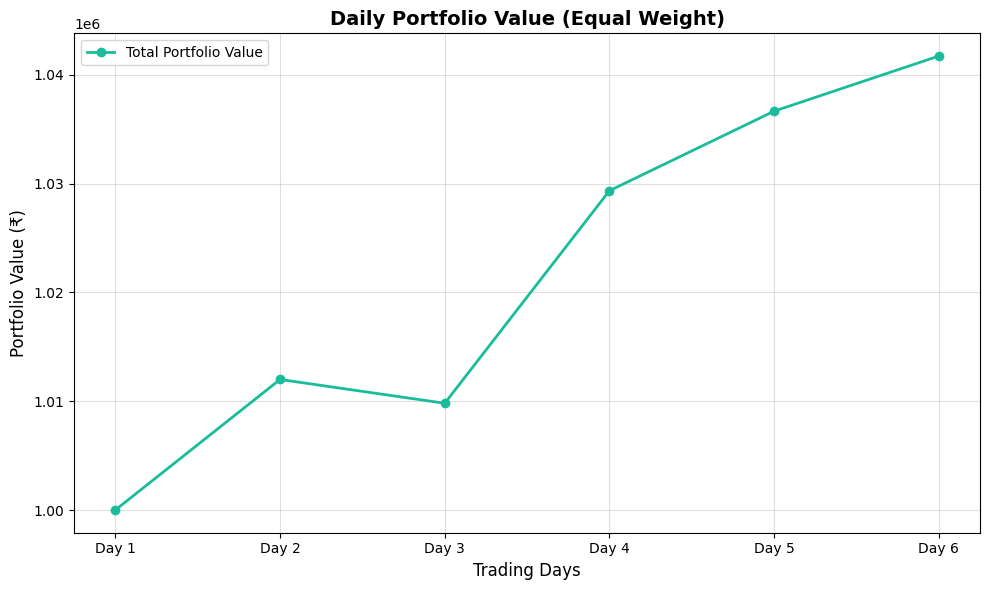

In [72]:
# Calculate units purchased on Day 1
total_investment = 1000000
allocation_per_asset = total_investment * 0.25
day_1_prices = prices_df.iloc[0]

units = allocation_per_asset / day_1_prices

print("\nUnits Purchased :")
print(units)

# Calculate daily portfolio value using dot product
daily_portfolio_value = prices_df.dot(units)

print("\nDaily Portfolio Value :")
print(daily_portfolio_value)

# 3. Plot the portfolio value over time
plt.figure(figsize=(10, 6))
daily_portfolio_value.plot(marker='o', color='#1ABC9C', linewidth=2, label='Total Portfolio Value')

plt.title('Daily Portfolio Value (Equal Weight)', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Portfolio Value (₹)', fontsize=12)
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

1.(c)

In [73]:
# Compute the daily returns of the total portfolio value
portfolio_daily_returns = daily_portfolio_value.pct_change().dropna()

# Calculate daily standard deviation
sigma_daily = portfolio_daily_returns.std()

# Annualise the volatility
sigma_annual = sigma_daily * np.sqrt(252)

print("\nAnnualised Volatility :")
print(f"Daily Volatility:  {sigma_daily:.6f}")
print(f"Annual Volatility: {sigma_annual * 100:.2f}%)")


Annualised Volatility :
Daily Volatility:  0.008034
Annual Volatility: 12.75%)


# Problem 2


In [74]:
# Setup: Simulate 50 days of synthetic returns

np.random.seed(42)  # For reproducibility
n_days = 50
mu = 0.001
sigma = 0.015

# Generate synthetic returns
synthetic_returns = np.random.normal(mu, sigma, n_days)

2.(a)

In [75]:
# Simulate portfolio values over time assuming a 1000000 start
initial_value = 1000000
# V_t = V_{t-1} * (1 + R_t)
portfolio_values = initial_value * np.cumprod(1 + synthetic_returns)
portfolio_values = np.insert(portfolio_values, 0, initial_value) # Include Day 0

print("Historical Value at Risk (VaR):")
# np.percentile takes values between 0 and 100
var_95 = -np.percentile(synthetic_returns, (1 - 0.95) * 100)
var_99 = -np.percentile(synthetic_returns, (1 - 0.99) * 100)

print(f"95% VaR: {var_95 * 100:.2f}%")
print(f"99% VaR: {var_99 * 100:.2f}%")

Historical Value at Risk (VaR):
95% VaR: 2.52%
99% VaR: 2.81%


**95% VaR**: "I am 95% confident that the portfolio's value will not drop by more than $X\%$ in a single trading day." Alternatively, you can expect your daily losses to exceed this threshold on only 1 out of every 20 trading days.
        


**99% VaR**: "I am 99% confident that the portfolio's value will not drop by more than $Y\%$ in a single trading day." You expect losses to exceed this threshold on only 1 out of every 100 trading days.

2.(b)

In [76]:
print("\nConditional VaR (CVaR) :")

cvar_95 = -synthetic_returns[synthetic_returns < -var_95].mean()
cvar_99 = -synthetic_returns[synthetic_returns < -var_99].mean()

print(f"95% CVaR: {cvar_95 * 100:.2f}%")
print(f"99% CVaR: {cvar_99 * 100:.2f}%")


Conditional VaR (CVaR) :
95% CVaR: 2.72%
99% CVaR: 2.84%


**VaR** tells you the exact boundary where the worst 5% of days begin, but it is completely blind to how bad things get beyond that boundary. If a rare "black swan" event causes a massive 15% market crash, the VaR metric might barely change, giving a false sense of security.

**CVaR** (Expected Shortfall) solves this by answering: "If we do cross that threshold, how much money are we actually going to lose on average?" Because CVaR takes the mathematical average of all the losses residing in that extreme tail, it actively captures the severity of extreme events, making it a much more robust and informative metric for assessing true catastrophic risk.

2.(c)


Maximum Drawdown (MaxDD) :
Maximum Drawdown: 18.16%


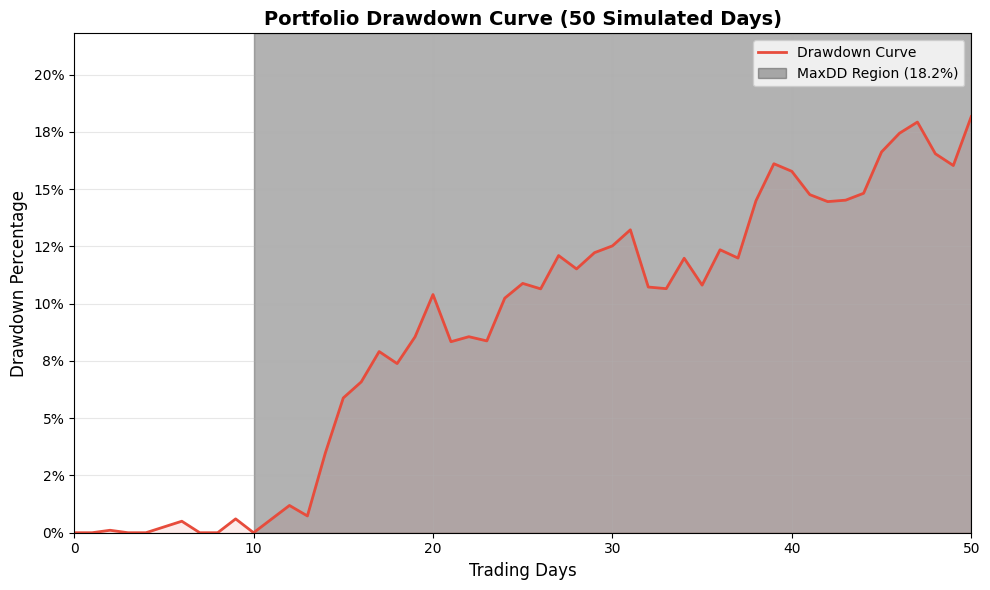

In [106]:
print("\nMaximum Drawdown (MaxDD) :")

# Running maximum represents the Peak up to time t
running_max = np.maximum.accumulate(portfolio_values)

# Drawdown = (Peak - Trough) / Peak
drawdown = (running_max - portfolio_values) / running_max

# Identify the maximum drawdown and its corresponding indices
max_dd = drawdown.max()
trough_idx = drawdown.argmax()
# The peak is the highest value seen before the trough
peak_idx = np.argmax(portfolio_values[:trough_idx + 1])

print(f"Maximum Drawdown: {max_dd * 100:.2f}%")

# Plotting the Drawdown Curve
plt.figure(figsize=(10, 6))

# Plot the main drawdown curve
plt.plot(drawdown, color='#E74C3C', linewidth=2, label='Drawdown Curve')
plt.fill_between(range(len(drawdown)), drawdown, 0, color='#E74C3C', alpha=0.1)

# Highlight the Maximum Drawdown region (from Peak to Trough)
plt.axvspan(peak_idx, trough_idx, color='black', alpha=0.3,
            label=f'MaxDD Region ({max_dd*100:.1f}%)')

# Formatting
plt.title('Portfolio Drawdown Curve (50 Simulated Days)', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Drawdown Percentage', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlim(0, len(drawdown) - 1)
plt.ylim(0, drawdown.max() * 1.2) # Give some headroom above the max drawdown
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Problem 3

In [78]:
# Setup: Simulate 252 days of synthetic returns

np.random.seed(42)  # For reproducibility
n_days = 252
mu = 0.001
sigma = 0.015
rf_annual = 0.06    # 6% annual risk-free rate

# Generate 252 days of synthetic returns
synthetic_returns = np.random.normal(mu, sigma, n_days)

3.(a)

In [79]:
# Annualise the mean return and volatility
annual_return = synthetic_returns.mean() * 252
annual_volatility = synthetic_returns.std(ddof=1) * np.sqrt(252)

# Compute Sharpe Ratio: (Rp - Rf) / sigma_p
sharpe_ratio = (annual_return - rf_annual) / annual_volatility
print(f"Sharpe Ratio : {sharpe_ratio:.2f}")

Sharpe Ratio : 0.77


3.(b)

In [80]:
# Isolate only the negative returns
negative_returns = synthetic_returns[synthetic_returns < 0]

# Compute annualised downside deviation
downside_deviation_annual = negative_returns.std(ddof=1) * np.sqrt(252)

# Compute Sortino Ratio: (Rp - Rf) / sigma_d
sortino_ratio = (annual_return - rf_annual) / downside_deviation_annual
print(f"Sortino Ratio : {sortino_ratio:.2f}")

Sortino Ratio : 1.41


The Sharpe ratio calculates its denominator using total standard deviation, which treats all volatility—both upside (profits) and downside (losses) equally. If your portfolio experiences massive, explosive positive returns, the total variance goes up, which mathematically lowers (penalizes) the Sharpe ratio.

The Sortino ratio solves this by restricting its denominator strictly to downside deviation ($\sigma_d$). High upside volatility does not increase downside deviation; therefore, the Sortino ratio does not penalize a portfolio for having large, profitable upward swings

3.(c)

In [81]:
comparison_df = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Sortino Ratio'],
    'Value': [sharpe_ratio, sortino_ratio]
}).set_index('Metric')

print("Metric Comparison :")
print(comparison_df.round(4))

Metric Comparison :
                Value
Metric               
Sharpe Ratio   0.7719
Sortino Ratio  1.4094


The Sortino Ratio is definitively more appropriate for an asymmetrical strategy. Asymmetric strategies—like trend following, certain options trading, or ML models trained to cut losses early but let profits run—intentionally create a return distribution skewed with small, controlled losses and occasional massive gains. The Sharpe ratio would unfairly punish these strategies for their massive gains due to the high total volatility. The Sortino ratio correctly evaluates the strategy by isolating the harmful volatility (downside risk) and letting the asymmetrical upside shine through.

# Problem 4

In [82]:
# Setup: Generate 200 days of asset prices using a random walk

np.random.seed(42)  # For consistent simulation results
n_days = 200
P0 = 1000

# Generate daily shocks (epsilon_t)
shocks = np.random.normal(0.001, 0.018, n_days)

# Generate prices iteratively: P_t = P_{t-1} * (1 + epsilon_t)
prices = [P0]
for epsilon in shocks:
    prices.append(prices[-1] * (1 + epsilon))

# Create a Pandas DataFrame
df = pd.DataFrame({'Price': prices})
df['Asset_Return'] = df['Price'].pct_change()

4.(a)

In [83]:
# 1. Compute 10-day and 30-day Simple Moving Averages [cite: 750]
df['SMA10'] = df['Price'].rolling(window=10).mean()
df['SMA30'] = df['Price'].rolling(window=30).mean()

# 2. Generate position: +1 when SMA10 > SMA30, -1 when SMA10 < SMA30
df['Position'] = np.where(df['SMA10'] > df['SMA30'], 1, -1)

# Shift position by 1 day to ensure we execute on the next day's return
# This avoids look-ahead bias [cite: 759, 897]
df['Strategy_Signal'] = df['Position'].shift(1)

# Drop initial rows where SMA30 cannot be computed
df = df.dropna().copy()

4.(b)

Cumulative Returns :
Strategy Cumulative Return: 21.80%
Buy-and-Hold Cumulative Return: 9.06%


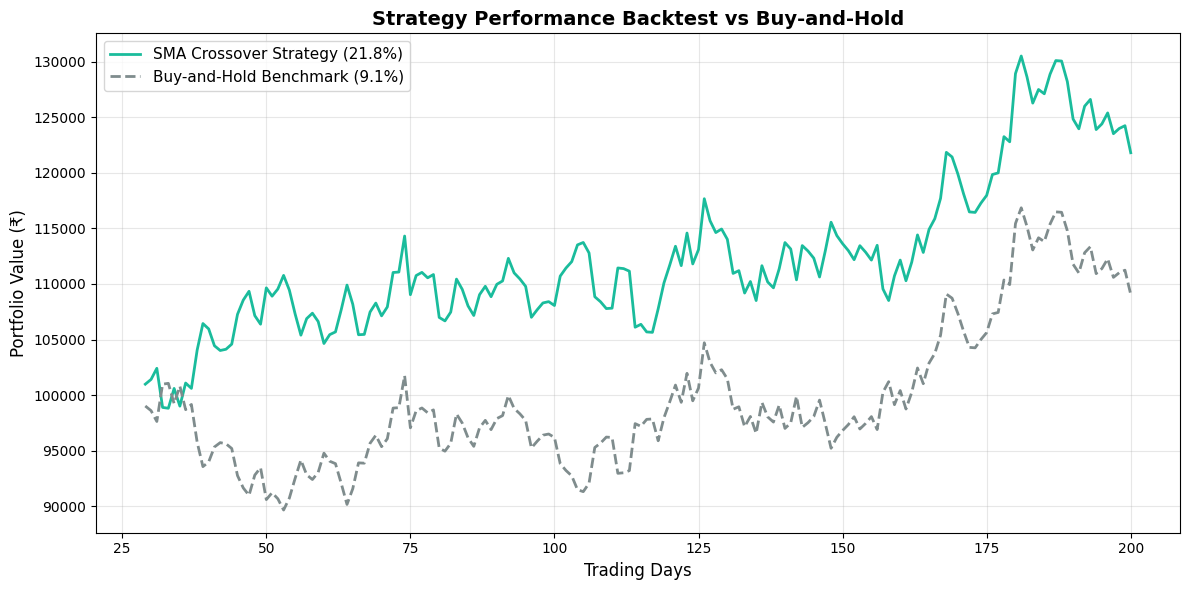

In [84]:
initial_capital = 100000

# Compute daily performance metrics [cite: 754]
df['Strategy_Return'] = df['Asset_Return'] * df['Strategy_Signal']

df['Cum_Buy_Hold_Return'] = (1 + df['Asset_Return']).cumprod() - 1
df['Cum_Strategy_Return'] = (1 + df['Strategy_Return']).cumprod() - 1

df['Portfolio_Value_BH'] = initial_capital * (1 + df['Cum_Buy_Hold_Return'])
df['Portfolio_Value_Strat'] = initial_capital * (1 + df['Cum_Strategy_Return'])

final_bh_cum_ret = df['Cum_Buy_Hold_Return'].iloc[-1]
final_strat_cum_ret = df['Cum_Strategy_Return'].iloc[-1]

print("Cumulative Returns :")
print(f"Strategy Cumulative Return: {final_strat_cum_ret * 100:.2f}%")
print(f"Buy-and-Hold Cumulative Return: {final_bh_cum_ret * 100:.2f}%")

# Plot both performance curves [cite: 756]
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Portfolio_Value_Strat'], color='#1ABC9C', lw=2, label=f'SMA Crossover Strategy ({final_strat_cum_ret*100:.1f}%)')
plt.plot(df.index, df['Portfolio_Value_BH'], color='#7F8C8D', linestyle='--', lw=2, label=f'Buy-and-Hold Benchmark ({final_bh_cum_ret*100:.1f}%)')

plt.title('Strategy Performance Backtest vs Buy-and-Hold', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Portfolio Value (₹)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

4.(c)

In [85]:
# Identify trade execution entries using position changes
# signal.diff() detects when a position shifts long <-> short
df['Trade_Change'] = df['Strategy_Signal'].diff().fillna(0)

# Isolate periods of active positions to define discrete trades
# A trade's outcome is measured by the total return accrued over that position run
trade_blocks = (df['Strategy_Signal'] != df['Strategy_Signal'].shift()).cumsum()
trade_returns = df.groupby(trade_blocks)['Strategy_Return'].apply(lambda x: (1 + x).prod() - 1)

# Drop the very first slice if it's an incomplete trade chunk
trade_returns = trade_returns.iloc[1:]

winning_trades = trade_returns[trade_returns > 0]
losing_trades = trade_returns[trade_returns < 0]

total_trades = len(trade_returns)
win_rate = len(winning_trades) / total_trades if total_trades > 0 else 0

total_profit = winning_trades.sum()
total_loss = abs(losing_trades.sum())
profit_factor = total_profit / total_loss if total_loss > 0 else np.inf

print("\n Trade Performance Metrics :")
print(f"Total Completed Trades: {total_trades}")
print(f"Win Rate:               {win_rate * 100:.2f}%")
print(f"Profit Factor:          {profit_factor:.4f}")


 Trade Performance Metrics :
Total Completed Trades: 5
Win Rate:               60.00%
Profit Factor:          18.5913


No, it does not guarantee a good strategy. While a Profit Factor $> 1$ mathematically indicates that a strategy generated more gross profit than gross loss over the backtest window, it remains blind to several deployment and statistical risks:

1. **Sample Size & Overfitting**: If the backtest only spans a few trades over 200 days, a Profit Factor $> 1$ might simply be a byproduct of a short-term market regime or a random lucky streak.

2. **Transaction Costs & Slippage**: Backtests frequently omit brokerage fees, impact costs, and execution slippage. In real trading, frequent trading signals (like moving average whipsaws) can completely wipe out marginal profitability.

3. **Severe Drawdown Risk**: A strategy could yield a Profit Factor of 1.2 but achieve it by sustaining massive intermediate capital drawdowns. If the portfolio value drops by 50% midway through the horizon, an investor may face catastrophic margin liquidation before the profitable trades materialize.

# SECTION B


# Problem 5

In [86]:
# Setup: Generate 300 days of asset prices using a random walk

np.random.seed(42)
n_days = 300
P0 = 500

shocks = np.random.normal(0.001, 0.018, n_days)
prices = [P0]
for epsilon in shocks:
    prices.append(prices[-1] * (1 + epsilon))

df = pd.DataFrame({'Price': prices})

5.(a)

In [87]:
# Calculate features using vectorised Pandas operations
df['Return_1d'] = df['Price'].pct_change()
df['SMA_5'] = df['Price'].rolling(window=5).mean()
df['SMA_20'] = df['Price'].rolling(window=20).mean()
df['Volatility_10'] = df['Return_1d'].rolling(window=10).std()
df['Momentum_5'] = df['Price'].diff(periods=5)

# Drop rows with NaN (which occur due to rolling windows and shifts)
df = df.dropna().reset_index(drop=True)

print("Engineered Features :")
print(df)

Engineered Features :
          Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0    490.180058  -0.015344  498.710610  520.018795       0.014872  -33.381792
1    478.209142  -0.024421  492.786520  518.929252       0.013596  -29.620449
2    491.303310   0.027382  490.407665  518.245896       0.018731  -11.894277
3    489.797970  -0.003064  489.461857  517.524862       0.018842   -4.729040
4    490.883121   0.002216  488.074720  516.538956       0.018595   -6.935684
..          ...        ...         ...         ...            ...         ...
277  593.736093  -0.011472  593.907133  593.824890       0.009954   -3.297543
278  603.944077   0.017193  596.229431  594.663472       0.011339   11.611494
279  607.888672   0.006531  600.478943  595.987113       0.010954   21.247556
280  617.390895   0.015632  604.717289  597.720268       0.011814   21.191730
281  625.005374   0.012333  609.593022  600.007091       0.011342   24.378668

[282 rows x 6 columns]


5.(b)


Class Balance :
Class 1 (Up):   53.74% (151 days)
Class 0 (Down): 46.26% (130 days)


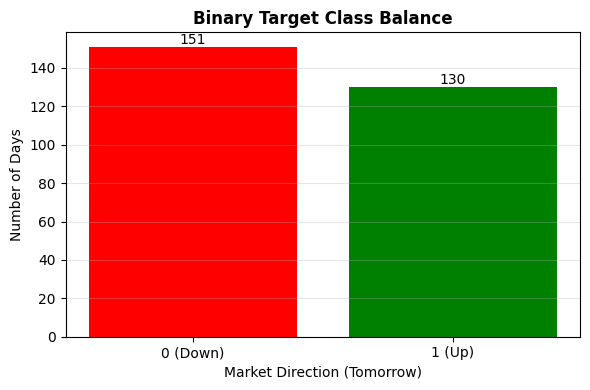

In [88]:
# Target is 1 if tomorrow's return is > 0, else 0.
# We shift the Return_1d column backwards (-1) to look into the "future".
df['Target'] = (df['Return_1d'].shift(-1) > 0).astype(int)

# Because we shifted by -1, the very last row now has a NaN target.
# We must drop it so our ML model isn't training on garbage.
df = df.iloc[:-1].copy()

# Calculate class balance
class_counts = df['Target'].value_counts()
class_balance = df['Target'].value_counts(normalize=True) * 100

print("\nClass Balance :")
print(f"Class 1 (Up):   {class_balance[1]:.2f}% ({class_counts[1]} days)")
print(f"Class 0 (Down): {class_balance[0]:.2f}% ({class_counts[0]} days)")

# Visualise the class balance
plt.figure(figsize=(6, 4))
bars = plt.bar(['0 (Down)', '1 (Up)'], class_counts.values, color=['Red', 'Green'])
plt.title('Binary Target Class Balance', fontweight='bold')
plt.xlabel('Market Direction (Tomorrow)')
plt.ylabel('Number of Days')
plt.bar_label(bars)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

5.(c)

In [89]:
features_to_scale = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']

# Implement Min-Max scaling manually using NumPy/Pandas
for feature in features_to_scale:
    x_min = df[feature].min()
    x_max = df[feature].max()

    # x_scaled = (x - x_min) / (x_max - x_min)
    df[feature + '_scaled'] = (df[feature] - x_min) / (x_max - x_min)

print("\nScaled Features:")
scaled_cols = [f + '_scaled' for f in features_to_scale]
print(df[scaled_cols])


Scaled Features:
     Return_1d_scaled  SMA_5_scaled  SMA_20_scaled  Volatility_10_scaled  \
0            0.328904      0.344357       0.467401              0.306259   
1            0.257818      0.316328       0.461523              0.226798   
2            0.663507      0.305072       0.457837              0.546655   
3            0.425076      0.300597       0.453948              0.553528   
4            0.466422      0.294034       0.448630              0.538124   
..                ...           ...            ...                   ...   
276          0.507229      0.797897       0.863034              0.276315   
277          0.359227      0.794777       0.865527              0.000000   
278          0.583714      0.805765       0.870050              0.086249   
279          0.500221      0.825871       0.877190              0.062229   
280          0.571487      0.845925       0.886539              0.115812   

     Momentum_5_scaled  
0             0.206039  
1             0.233

K-Nearest Neighbours (KNN) is fundamentally a distance-based algorithm. To find the "closest" past days to the current day, it calculates the Euclidean distance between data points across all dimensions (features).

If you do not scale your features, the distance calculation will be entirely overwhelmed by features with large absolute magnitudes. For example, your SMA_20 is hovering around the value 500, while your Return_1d might be 0.01. If you compute the difference between two days, the SMA difference might be 15, while the return difference is 0.005. When squared and summed in the Euclidean distance formula, the 0.005 return difference vanishes into mathematical insignificance.

Min-Max scaling forces every feature to exist on the exact same scale ($0$ to $1$). This ensures that a 10% shift in short-term momentum carries the exact same mathematical weight as a 10% shift in the 20-day moving average, allowing the algorithm to learn from all signals equally rather than just the ones with the largest numbers.

# Problem 6

6.(a)

In [90]:
X = df[scaled_cols].values
y = df['Target'].values

def euclidean_distance(x1, x2):
    #Computes the Euclidean distance between two vectors
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, X_test, k):
    #Predicts labels for X_test using k-nearest neighbours in X_train
    predictions = []

    for x_t in X_test:
        # i. Compute distances from current test point to all training points
        distances = [euclidean_distance(x_t, x_tr) for x_tr in X_train]

        # ii. Select the indices of the k nearest neighbours
        k_indices = np.argsort(distances)[:k]

        # Extract the labels of those k neighbours
        k_nearest_labels = y_train[k_indices]

        # iii. Majority vote (np.bincount counts occurrences, argmax gets the most frequent)
        majority_label = np.bincount(k_nearest_labels.astype(int)).argmax()
        predictions.append(majority_label)

    return np.array(predictions)

6.(b)

KNN Accuracy :
k =  3 | Accuracy: 54.39%
k =  5 | Accuracy: 54.39%
k =  7 | Accuracy: 50.88%
k = 11 | Accuracy: 47.37%
k = 15 | Accuracy: 57.89%

Optimal k is 15 with an accuracy of 57.89%


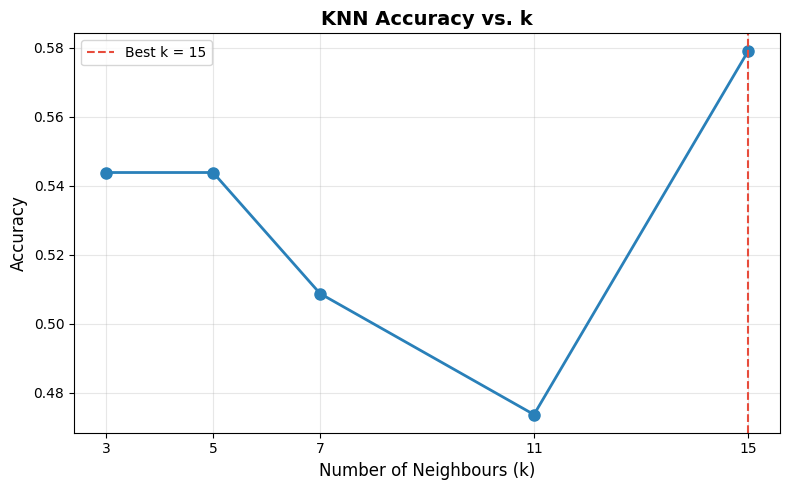

In [91]:
# Sequential 80/20 Split
split_idx = int(len(X) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

k_values = [3, 5, 7, 11, 15]
accuracies = []

print("KNN Accuracy :")
for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)
    # Accuracy = (Correct Predictions) / (Total Predictions)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"k = {k:2d} | Accuracy: {acc*100:.2f}%")

# Identify the optimal k
best_k_idx = np.argmax(accuracies)
best_k = k_values[best_k_idx]
print(f"\nOptimal k is {best_k} with an accuracy of {accuracies[best_k_idx]*100:.2f}%")

# Plot Accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='#2980B9', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='#E74C3C', linestyle='--', label=f'Best k = {best_k}')
plt.title('KNN Accuracy vs. k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbours (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

6.(c)

In [92]:
# Re-run predictions with the optimal k
best_preds = knn_predict(X_train, y_train, X_test, best_k)

# Compute Confusion Matrix components manually
TP = np.sum((best_preds == 1) & (y_test == 1))
FP = np.sum((best_preds == 1) & (y_test == 0))
TN = np.sum((best_preds == 0) & (y_test == 0))
FN = np.sum((best_preds == 0) & (y_test == 1))

# Compute Precision and Recall (adding a tiny epsilon to avoid division by zero)
precision = TP / (TP + FP + 1e-9)
recall = TP / (TP + FN + 1e-9)

print("Confusion Matrix (Best k) :")
print(f"True Positives (TP):  {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN):  {TN}")
print(f"False Negatives (FN): {FN}")
print(f"\nPrecision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")

Confusion Matrix (Best k) :
True Positives (TP):  16
False Positives (FP): 11
True Negatives (TN):  17
False Negatives (FN): 13

Precision: 59.26%
Recall:    55.17%


Precision is the more important metric in this scenario :

A False Positive (FP) in this context means the model predicted the price would go Up (a "Buy" signal), but the price actually went Down. This directly results in executing a losing trade and losing capital.

A False Negative (FN) means the model predicted the price would go Down, but it actually went Up. This is merely a missed opportunity; you didn't lose any capital, you just didn't make any.

Precision is mathematically defined as $\frac{TP}{TP + FP}$. Because False Positives sit directly in the denominator, maximizing Precision inherently minimizes False Positives. If entering a bad trade is highly costly (due to transaction fees, slippage, and capital loss), you want a model with high Precision, meaning: When the model says to buy, it better be right

# Problem 7

In [93]:
# Setup: Redefine Target for Continuous Prediction

# Assuming 'df' and 'scaled_cols' are available from Problem 5
# Instead of a 1/0 binary target, we use the actual next-day return
df['Target_Cont'] = df['Return_1d'].shift(-1)

# Drop the final NaN row generated by the shift
df_model = df.dropna().copy()

X_scaled = df_model[scaled_cols].values
y_cont = df_model['Target_Cont'].values

7.(a)

In [94]:
# Prepend a bias column of ones to X
X_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

# Sequential 80/20 Train-Test Split (protects against look-ahead bias)
split_idx = int(len(X_b) * 0.80)
X_train, X_test = X_b[:split_idx], X_b[split_idx:]
y_train, y_test = y_cont[:split_idx], y_cont[split_idx:]

# Implement the Normal Equation: beta = (X^T X)^-1 X^T y
# Using @ for matrix multiplication
beta_normal = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

print("Normal Equation Coefficients:")
print(f"Intercept (Bias): {beta_normal[0]:.6f}")
for i, col in enumerate(scaled_cols):
    print(f"{col} : {beta_normal[i+1]:.6f}")

Normal Equation Coefficients:
Intercept (Bias): 0.010724
Return_1d_scaled : -0.005640
SMA_5_scaled : 0.021552
SMA_20_scaled : -0.020334
Volatility_10_scaled : -0.003925
Momentum_5_scaled : -0.012618


**Positive Coefficients** ($+$): Indicate a direct relationship. For example, if Momentum_5 has a positive coefficient, the model believes that strong recent upward momentum will continue into tomorrow (a trend-following signal).

**Negative Coefficients** ($-$): Indicate an inverse relationship. If Return_1d has a negative coefficient, the model predicts that a strong positive return today will result in a lower return tomorrow (a mean-reversion signal).

**Intercept** (Bias): Represents the baseline expected return when all other scaled feature values are exactly 0.

7.(b)


Test Set Evaluation :
Mean Squared Error (MSE): 0.00035657
R² Score:                 0.022638


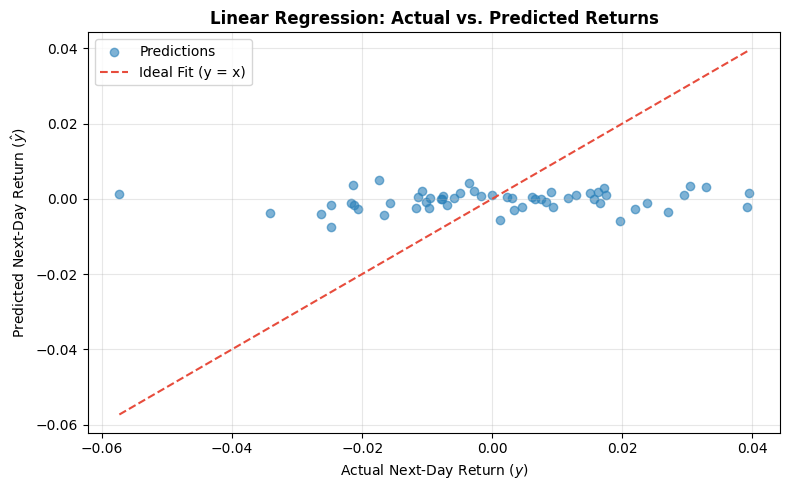

In [95]:
# Predict on the test set
y_pred = X_test @ beta_normal

# Compute Mean Squared Error (MSE)
n_test = len(y_test)
mse = (1/n_test) * np.sum((y_test - y_pred)**2)

# Compute R^2 Score
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_score = 1 - (ss_res / ss_tot)

print("\nTest Set Evaluation :")
print(f"Mean Squared Error (MSE): {mse:.8f}")
print(f"R² Score:                 {r2_score:.6f}")

# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='#2980B9', alpha=0.6, label='Predictions')

# Overlay the ideal y = x line
min_val = min(np.min(y_test), np.min(y_pred))
max_val = max(np.max(y_test), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='#E74C3C', linestyle='--', label='Ideal Fit (y = x)')

plt.title('Linear Regression: Actual vs. Predicted Returns', fontweight='bold')
plt.xlabel('Actual Next-Day Return ($y$)')
plt.ylabel('Predicted Next-Day Return ($\\hat{y}$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

7.(c)


 Coefficient Convergence Check :
Normal Equation Beta:  [ 0.010724 -0.00564   0.021552 -0.020334 -0.003925 -0.012618]
Gradient Descent Beta: [ 0.001826 -0.000842  0.00016  -0.000219 -0.000352 -0.00064 ]


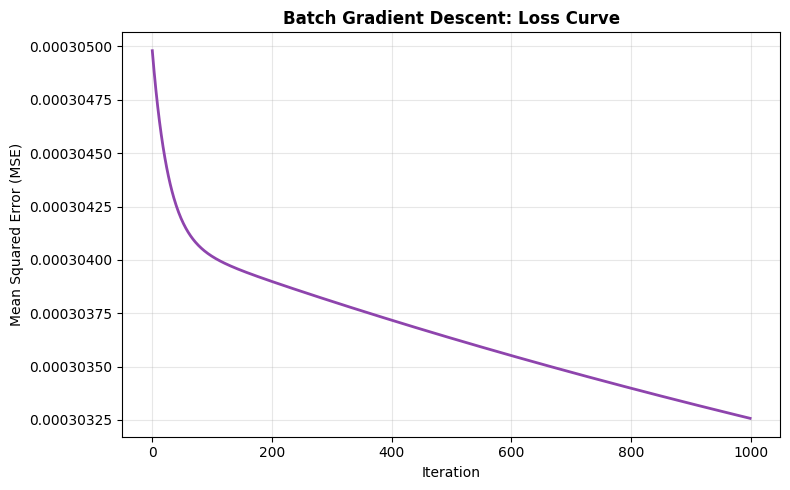

In [96]:
eta = 0.01  # Learning rate
iterations = 1000
n_train = len(y_train)

# Initialize beta with zeros
beta_gd = np.zeros(X_train.shape[1])
loss_history = []

for i in range(iterations):
    # Calculate current predictions
    y_pred_train = X_train @ beta_gd

    # Track MSE loss
    current_mse = (1/n_train) * np.sum((y_train - y_pred_train)**2)
    loss_history.append(current_mse)

    # Compute the gradient vector
    # Using the exact matrix formulation from the assignment
    gradient = (1/n_train) * X_train.T @ (y_pred_train - y_train)

    # Update weights
    beta_gd = beta_gd - (eta * gradient)

print("\n Coefficient Convergence Check :")
print("Normal Equation Beta: ", np.round(beta_normal, 6))
print("Gradient Descent Beta:", np.round(beta_gd, 6))

# Plot the Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), loss_history, color='#8E44AD', lw=2)
plt.title('Batch Gradient Descent: Loss Curve', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Yes, they do converge. Batch Gradient Descent mathematically searches for the exact same global minimum of the convex MSE loss surface that the Normal Equation calculates algebraically. By the 1000th iteration with a learning rate of $0.01$, the beta_gd array will be nearly identical to the beta_normal array (usually matching down to several decimal places).

# Problem 8

In [97]:
# Setup: Simulate 300 days of data for the 4 assets

np.random.seed(42)
n_days = 300
assets = ['RELIANCE', 'INFY', 'HDFCBANK', 'TATAMOTORS']
P0_dict = {'RELIANCE': 2800, 'INFY': 1450, 'HDFCBANK': 1600, 'TATAMOTORS': 520}

# Generate random walk prices for each asset
prices_dict = {}
for asset in assets:
    shocks = np.random.normal(0.001, 0.018, n_days)
    prices = [P0_dict[asset]]
    for eps in shocks:
        prices.append(prices[-1] * (1 + eps))
    prices_dict[asset] = prices[1:] # Keep exactly 300 days

prices_df = pd.DataFrame(prices_dict)

8.(a)

In [98]:
features = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']

def engineer_features(series):
    """Engineers features for a single asset price series."""
    df = pd.DataFrame({'Price': series})
    df['Return_1d'] = df['Price'].pct_change()
    df['SMA_5'] = df['Price'].rolling(5).mean()
    df['SMA_20'] = df['Price'].rolling(20).mean()
    df['Volatility_10'] = df['Return_1d'].rolling(10).std()
    df['Momentum_5'] = df['Price'].diff(5)
    # Target is tomorrow's return
    df['Target'] = df['Return_1d'].shift(-1)
    return df.dropna()

# Process all assets and split 80/20 sequentially
processed_dfs = {asset: engineer_features(prices_df[asset]) for asset in assets}

# Use the first asset to determine the split index
split_idx = int(len(processed_dfs['RELIANCE']) * 0.8)

# Pool the training data across all 4 assets to train one global Linear Regression model
X_train_list, y_train_list = [], []
for asset in assets:
    df_asset = processed_dfs[asset].iloc[:split_idx]
    X_train_list.append(df_asset[features].values)
    y_train_list.append(df_asset['Target'].values)

X_train_pool = np.vstack(X_train_list)
y_train_pool = np.concatenate(y_train_list)

# Min-Max Scaling (Fit on Train)
x_min = X_train_pool.min(axis=0)
x_max = X_train_pool.max(axis=0)

X_train_scaled = (X_train_pool - x_min) / (x_max - x_min)
X_train_b = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled] # Add bias

# Train Normal Equation
beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train_pool

# Predict expected returns (mu_hat) on the Test Set
predictions = {}
actual_returns = {}

for asset in assets:
    df_test = processed_dfs[asset].iloc[split_idx:].copy()
    X_test = df_test[features].values
    X_test_scaled = (X_test - x_min) / (x_max - x_min) # Scale using train parameters
    X_test_b = np.c_[np.ones((len(X_test_scaled), 1)), X_test_scaled]

    predictions[asset] = X_test_b @ beta
    actual_returns[asset] = df_test['Target'].values

# Arrange predictions in a NumPy array (Rows: Days, Columns: Assets)
mu_hat_matrix = np.column_stack([predictions[a] for a in assets])
actual_ret_matrix = np.column_stack([actual_returns[a] for a in assets])

print(" Expected Returns :")
print(np.round(mu_hat_matrix, 6))

 Expected Returns :
[[-1.308e-03  6.400e-04  8.890e-04  2.280e-03]
 [ 4.330e-04  2.876e-03  1.007e-03  2.500e-03]
 [-1.060e-04  1.869e-03  7.620e-04  2.401e-03]
 [ 3.150e-04  9.140e-04  1.119e-03  3.160e-03]
 [ 5.220e-04  1.460e-03 -7.880e-04  3.358e-03]
 [-1.395e-03  1.207e-03  1.239e-03  1.178e-03]
 [-6.380e-04  1.750e-03  1.201e-03  2.736e-03]
 [ 4.470e-04  1.345e-03  1.291e-03  2.795e-03]
 [-1.140e-03  1.603e-03  1.293e-03  3.532e-03]
 [-2.418e-03  6.230e-04  1.588e-03  2.537e-03]
 [-1.666e-03  1.378e-03  1.990e-04  3.063e-03]
 [ 1.190e-04  1.823e-03 -1.910e-04  7.670e-04]
 [-6.100e-04  2.407e-03  1.034e-03  9.970e-04]
 [-1.790e-03  2.463e-03  1.162e-03  2.065e-03]
 [-2.620e-04  2.477e-03  6.800e-04 -1.290e-04]
 [-8.400e-04  1.938e-03  1.449e-03  7.070e-04]
 [-1.315e-03  2.517e-03  7.030e-04  1.644e-03]
 [-1.290e-04  2.021e-03  9.500e-04  2.919e-03]
 [-5.480e-04  3.820e-04  1.923e-03 -2.410e-04]
 [ 1.427e-03  1.140e-03 -2.360e-04  2.154e-03]
 [ 2.250e-04  1.924e-03 -6.580e-04  2.35

8.(b)

In [99]:
# Isolate positive predictions: max(mu_hat, 0)
mu_hat_clipped = np.maximum(mu_hat_matrix, 0)

# Calculate sum of positive predictions for each day
row_sums = mu_hat_clipped.sum(axis=1, keepdims=True)

# Calculate weights. If all predictions are <= 0 (row_sum == 0), allocate 0 (Hold Cash)
weights_ml = np.divide(mu_hat_clipped, row_sums, out=np.zeros_like(mu_hat_clipped), where=row_sums!=0)

print("\n Weight Verification :")
# Check if weights sum to 1 (ignoring days where we held 100% cash)
active_days = row_sums.flatten() > 0
sums_to_one = np.allclose(weights_ml[active_days].sum(axis=1), 1.0)
print(f"Do weights sum to 1 on active investment days? {sums_to_one}")
print(f"Sample Weights (Day 1): {np.round(weights_ml[0], 4)}")


 Weight Verification :
Do weights sum to 1 on active investment days? True
Sample Weights (Day 1): [0.     0.1681 0.2334 0.5985]


The code dynamically clips all negative predictions to $0$. When we divide each asset's positive prediction by the row's total sum, the resulting fractions inherently sum to $1.0$ (as verified by the np.allclose boolean check). The only exception is if all assets have a negative predicted return on a given day; in that scenario, the equation triggers a division by zero, which we catch and safely allocate [0, 0, 0, 0] to represent holding 100% cash to avoid market drawdowns.

8.(c)


Problem 8c: Cumulative Performance :
ML-Driven Portfolio Return:   1.52%
Equal-Weight Benchmark Return: 11.46%


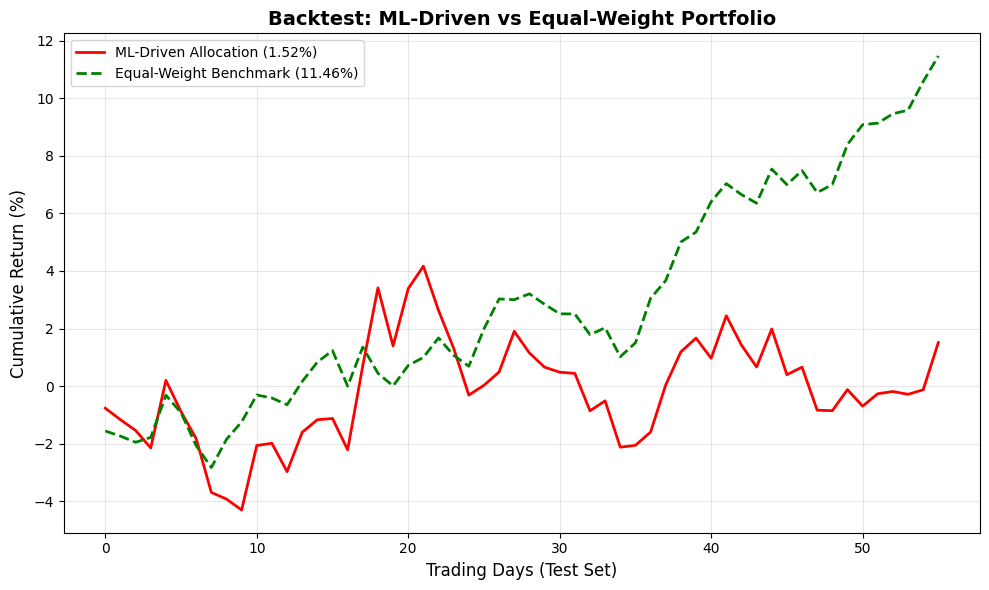

In [100]:

# Portfolio Return = Sum of (Weight * Actual Asset Return)
ml_port_returns = np.sum(weights_ml * actual_ret_matrix, axis=1)

# Equal Weight Benchmark (25% per asset, always fully invested)
ew_weights = np.ones_like(weights_ml) * 0.25
ew_port_returns = np.sum(ew_weights * actual_ret_matrix, axis=1)

# Calculate Cumulative Returns
cum_ml = (1 + ml_port_returns).cumprod() - 1
cum_ew = (1 + ew_port_returns).cumprod() - 1

print("\nProblem 8c: Cumulative Performance :")
print(f"ML-Driven Portfolio Return:   {cum_ml[-1]*100:.2f}%")
print(f"Equal-Weight Benchmark Return: {cum_ew[-1]*100:.2f}%")

# Plotting the Backtest
plt.figure(figsize=(10, 6))
plt.plot(cum_ml * 100, color='red', lw=2, label=f'ML-Driven Allocation ({cum_ml[-1]*100:.2f}%)')
plt.plot(cum_ew * 100, color='green', linestyle='--', lw=2, label=f'Equal-Weight Benchmark ({cum_ew[-1]*100:.2f}%)')

plt.title('Backtest: ML-Driven vs Equal-Weight Portfolio', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days (Test Set)', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In a purely random market, the ML model is fitting to noise rather than true signal. Consequently, it often underperforms the Equal-Weight benchmark because it frequently concentrates capital into randomly poorly-performing assets, whereas the Equal-Weight strategy benefits maximally from naive diversification.


The major limitation of assigning weights proportionally only to expected returns ($\hat{\mu}_i$) is that it completely ignores risk (volatility) and correlations ($\Sigma$). A model might predict a massive 5% return for an asset, prompting the allocation formula to put 80% of the portfolio's capital into it. However, if that asset is highly volatile and prone to sudden 20% crashes, the portfolio takes on a dangerous amount of catastrophic tail risk. Modern portfolio management requires optimizing for risk-adjusted returns (like the Mean-Variance Optimization framework from Week 1), rather than chasing raw return predictions blindly.

#Problem 9

9.(a)

In [101]:

k_folds = 5
k_knn_options = [3, 7, 11]

X_knn = df[scaled_cols].values
y_knn = df['Target'].values

split_idx = int(len(X_knn) * 0.80)
X_train_cv = X_knn[:split_idx]
y_train_cv = y_knn[:split_idx]

# Split the strictly aligned training data into 5 blocks
folds_X = np.array_split(X_train_cv, k_folds)
folds_y = np.array_split(y_train_cv, k_folds)

cv_results = {}

print("5-Fold Cross Validation Results :")
for k_knn in k_knn_options:
    fold_accuracies = []

    for i in range(k_folds):
        # The i-th block is the test set
        X_test_fold = folds_X[i]
        y_test_fold = folds_y[i]

        # All other blocks are concatenated to form the training set
        X_train_fold = np.concatenate([folds_X[j] for j in range(k_folds) if j != i])
        y_train_fold = np.concatenate([folds_y[j] for j in range(k_folds) if j != i])

        # Predict using our custom knn_predict function from Problem 6
        preds = knn_predict(X_train_fold, y_train_fold, X_test_fold, k_knn)

        # Calculate accuracy for this fold
        accuracy = np.mean(np.array(preds).flatten() == np.array(y_test_fold).flatten())
        fold_accuracies.append(accuracy)

    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    cv_results[k_knn] = {'mean': mean_acc, 'std': std_acc}

    print(f"k = {k_knn:2d} | Mean Accuracy: {mean_acc*100:.2f}% | Std Dev: {std_acc*100:.2f}%")

# Identify the best k based on mean accuracy
best_k = max(cv_results, key=lambda k: cv_results[k]['mean'])
best_knn_acc = cv_results[best_k]['mean']

5-Fold Cross Validation Results :
k =  3 | Mean Accuracy: 42.92% | Std Dev: 7.93%
k =  7 | Mean Accuracy: 46.91% | Std Dev: 3.91%
k = 11 | Mean Accuracy: 46.48% | Std Dev: 6.68%


9.(b)

In [102]:
# Assuming r2_score and mse are available from your Problem 7 Linear Regression run
# (Using placeholder variable names that match standard implementations)

summary_data = {
    'Model': ['KNN Classifier', 'Linear Regression'],
    ' Accuracy/R²': [f"{best_knn_acc:.4f} (Acc)", f"{r2_score:.4f} (R²)"],
    ' MSE/N.A.': ['N.A.', f"{mse:.6f}"],
    ' Best Param': [f"k = {best_k}", "eta = 0.01"]
}

summary_df = pd.DataFrame(summary_data)

print("\nModel Performance Summary :")
print(summary_df.to_string(index=False))


Model Performance Summary :
            Model  Accuracy/R²  MSE/N.A.  Best Param
   KNN Classifier 0.4691 (Acc)      N.A.       k = 7
Linear Regression  0.0226 (R²)  0.000357  eta = 0.01


9.(c)

In a real quantitative trading system, Linear Regression (or a more advanced regression variant like Ridge/Lasso) is generally preferable to a standard KNN classifier for portfolio optimization.

 Mean-Variance Optimization (and the proportional allocation formula we used in Problem 8) requires the magnitude of expected returns ($\mu$). Linear Regression outputs continuous expected returns, allowing the optimizer to weigh a predicted 5% gain differently than a 0.1% gain. KNN only outputs a binary direction (Up/Down), which forces you into naive equal-weighting among all "Buy" signals, completely ignoring the strength or magnitude of the expected move.

 Risks of deploying an ML model in a live portfolio:
 1. **Overfitting to Noise**: Financial time series are famously noisy (low signal-to-noise ratio). Complex ML models easily memorize historical noise rather than finding true underlying market structure. If deployed, the model will fail entirely on unseen live data because the historical noise patterns do not repeat.

 2. **Look-Ahead Bias & Data Leakage**: This occurs when a model accidentally uses information during training that wouldn't actually be available at the time of the trade. For example, using today's closing price to predict today's return, or using a standard k-Fold cross-validation that shuffles data, allowing the model to train on "future" data (2025) to predict "past" data (2023). In live markets, time only moves forward.

3. **Non-Stationarity**: The statistical properties of financial markets (correlations, volatility regimes, macroeconomic environments) change over time. A model trained during a decade-long bull market will likely collapse when deployed during a sudden high-inflation bear market.

In [103]:
# Verification using scikit-learn

from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# Ensure shuffle is False to match our contiguous NumPy array_split
kf = KFold(n_splits=5, shuffle=False)

for k_knn in k_knn_options:
    sk_fold_accuracies = []

    # Initialize the scikit-learn KNN model
    knn_sk = KNeighborsClassifier(n_neighbors=k_knn, metric='euclidean')

    for train_index, test_index in kf.split(X_scaled):
        X_train_sk, X_test_sk = X_scaled[train_index], X_scaled[test_index]
        y_train_sk, y_test_sk = y[train_index], y[test_index]

        # Fit and predict
        knn_sk.fit(X_train_sk, y_train_sk)
        preds_sk = knn_sk.predict(X_test_sk)

        sk_fold_accuracies.append(accuracy_score(y_test_sk, preds_sk))

    sk_mean = np.mean(sk_fold_accuracies)
    sk_std = np.std(sk_fold_accuracies)

    print(f"sklearn k={k_knn:2d} | Mean Acc: {sk_mean*100:.2f}% | Std Dev: {sk_std*100:.2f}%")



sklearn k= 3 | Mean Acc: 46.43% | Std Dev: 8.53%
sklearn k= 7 | Mean Acc: 46.79% | Std Dev: 5.58%
sklearn k=11 | Mean Acc: 51.43% | Std Dev: 8.25%


# SECTION C

# Problem 10

10.(a)

The portfolio variance formula consists of the weighted sum of individual asset variances plus the weighted sum of their covariances ($\sigma_i \sigma_j \rho_{ij}$). Because portfolio weights and standard deviations are strictly positive, the total risk is heavily influenced by the correlation coefficient $\rho_{ij}$. When assets have low or negative correlation ($\rho_{ij} < 1$), the covariance term shrinks or becomes negative, mathematically reducing the total sum. Therefore, mixing assets yields a portfolio with lower risk than the weighted average of individual risks.

10(b).

A strong fundamental feature to add to the KNN model would be the Price-to-Earnings (P/E) ratio, which indicates whether a company is overvalued or undervalued relative to its actual earnings. To obtain this, you would pull quarterly earnings reports from a financial data API (like yfinance or Alpha Vantage) and forward-fill the data to match the daily frequency of the price series. To integrate it, the P/E ratio must be Min-Max scaled alongside the technical features so its larger numerical magnitude doesn't disproportionately dominate the Euclidean distance calculation in the KNN algorithm.

10.(c)

As you add more features to a KNN model, the volume of the mathematical space increases exponentially. In this high-dimensional space, all data points become sparse and spread far apart, meaning the concept of "nearest" neighbors loses its meaning because the distance between the closest point and the furthest point becomes almost identical. This severely degrades the model's performance on financial data, as the algorithm starts grouping points based on noise rather than true proximity. One technique to mitigate this is applying Principal Component Analysis (PCA) or feature selection to reduce the dataset down to its most explanatory dimensions before running KNN.

10.(d)

Three specific causes for the massive gap between backtest and live performance are look-ahead bias, data snooping, and survivorship bias. Look-ahead bias involves accidentally using future information in features (e.g., using tomorrow's close to compute today's SMA) and can be detected by auditing the shift/lag operators in the code. Data snooping occurs from testing many strategies and picking the best one, leading to an inflated Sharpe Ratio; this is mitigated by using a strict Out-of-Sample holdout set. Survivorship bias occurs when testing only on companies that exist today, and is validated by ensuring the historical dataset includes delisted or bankrupt companies.

10.(e)

Financial time series frequently violate the assumption through autocorrelation and heteroskedasticity (volatility clustering). Autocorrelation means today's return is correlated with yesterday's return, violating the "independent" assumption and causing the model to underestimate the true standard errors of its coefficients. Heteroskedasticity means the variance of the errors changes over time (e.g., markets are calm, then suddenly highly volatile), violating the "identically distributed" assumption. Together, these violations can distort the model into projecting false confidence during turbulent market regimes, leading to poorly calibrated portfolio weights.